# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Load Dataset

In [2]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Basic exploration

In [3]:
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

(200, 5)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000           61.500

# Encode Gender

In [4]:
le = LabelEncoder()

df["Gender"] = le.fit_transform(df["Gender"])

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


# Select Feature

In [5]:
X = df[[
    "Gender",
    "Age",
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# Feature Scalling

In [6]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Find Optimal K (Elbow Method)

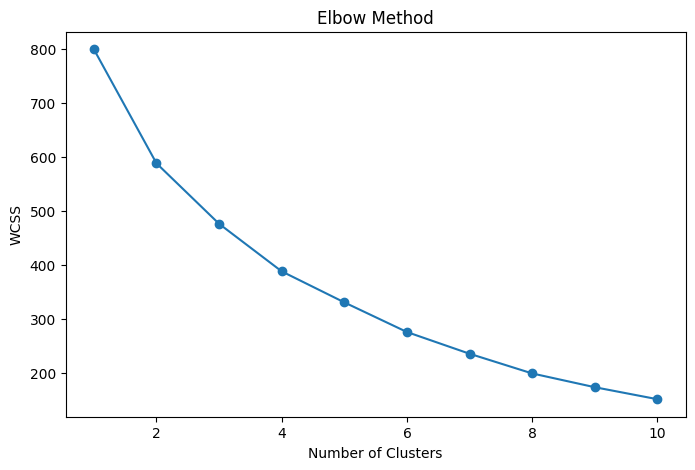

In [7]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.show()

# Train K Mean

In [8]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

# Cluster Distribution

In [9]:
df["Cluster"].value_counts()

Cluster
3    54
2    43
0    39
4    35
1    29
Name: count, dtype: int64

# PCA VIsualization 

In [10]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(X_scaled)

df["PCA1"] = pca_features[:,0]

df["PCA2"] = pca_features[:,1]

# Plot Cluster

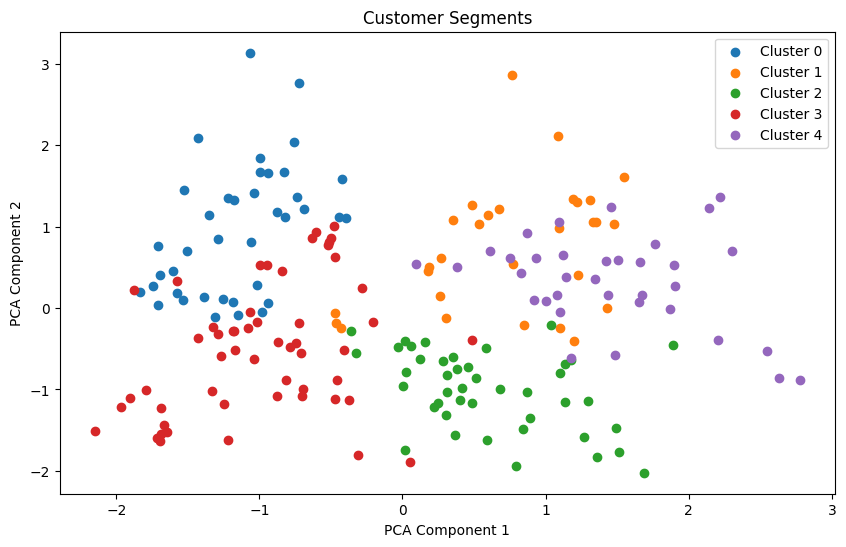

In [11]:
plt.figure(figsize=(10,6))

for cluster in range(5):

    subset = df[df["Cluster"] == cluster]

    plt.scatter(
        subset["PCA1"],
        subset["PCA2"],
        label=f"Cluster {cluster}"
    )

plt.title("Customer Segments")

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.legend()

plt.show()

# Cluster Analysis

In [12]:
cluster_summary = df.groupby("Cluster").mean()

print(cluster_summary)

         CustomerID    Gender        Age  Annual Income (k$)  \
Cluster                                                        
0        162.000000  0.461538  32.692308           86.538462   
1        165.482759  0.448276  36.482759           89.517241   
2         73.651163  0.000000  49.813953           49.232558   
3         52.814815  0.407407  24.907407           39.722222   
4         84.685714  1.000000  55.714286           53.685714   

         Spending Score (1-100)      PCA1      PCA2  
Cluster                                              
0                     82.128205 -1.151299  0.959764  
1                     18.000000  0.739004  0.744866  
2                     40.069767  0.606362 -1.008718  
3                     61.203704 -0.992308 -0.501973  
4                     36.771429  1.456589  0.327129  


# Conclusion

In [ ]:
# 1. Successfully segmented customers using K-Means.
# 2. Elbow Method suggested 5 clusters.
# 3. PCA was used for cluster visualization.
# 4. Each cluster represents different purchasing behavior.
# 5. Business can target customers with personalized marketing strategies.